# BÀI TẬP LỚN MACHINE LEARNING
## Notebook 01: Kiểm định Cấu trúc & Chất lượng Dữ liệu Thô (Data Quality & Inspection)

**Mục tiêu của Notebook:**
1. Đọc và khám phá tập dữ liệu thô từ `data/raw/bank.csv`.
2. Trích xuất các thông số kỹ thuật: kích thước dữ liệu, danh sách các cột, kiểu dữ liệu (`int64`, `float64`, `object`/`str`).
3. Đánh giá chất lượng dữ liệu:
   - Thống kê tỷ lệ khuyết thiếu dữ liệu (Missing Values) chuẩn (`NaN`) và dạng ngầm định (`'unknown'`).
   - Xuất biểu đồ ma trận Missing Values lưu vào `figures/01_missing_values.png`.
   - Kiểm tra dữ liệu trùng lặp (Duplicated Rows).
   - Phát hiện các giá trị bất thường (giá trị âm, định dạng chuỗi bất thường).
4. Phân tích độ phân tán và phát hiện ngoại lai (Outliers) qua Biểu đồ hộp (Boxplot) & phương pháp IQR.
5. Tổng hợp bảng thông số cấu trúc dữ liệu phục vụ **Mục 2.1 của Báo cáo**.


**Ghi chú tích hợp:** Nội dung, trình tự và cách trình bày của Trí được giữ nguyên. Chỉ đổi đường dẫn sang `data/raw/bank.csv`, sửa ký tự thừa làm notebook không chạy, khai báo bảng báo cáo vốn phụ thuộc hidden state, và tách mã sentinel `pdays = -1` khỏi phép sàng lọc IQR.


### 1. Khởi tạo Thư viện và Thiết lập Môi trường
Import các thư viện phân tích dữ liệu cơ bản (`pandas`, `numpy`) và trực quan hóa (`matplotlib`, `seaborn`).
Sử dụng `pathlib.Path` để đường dẫn luôn chính xác dù notebook được chạy từ thư mục gốc hay thư mục `notebooks/`.


In [1]:
import os
import sys
from pathlib import Path
from IPython.display import display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập hiển thị bảng dữ liệu của pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# Cấu hình thẩm mỹ đồ thị seaborn
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

# Xác định đường dẫn gốc của dự án (Project Root)
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "bank.csv"
FIGURES_PATH = PROJECT_ROOT / "figures"

# Đảm bảo thư mục figures tồn tại
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset path: {DATA_PATH}")
print(f"Figures path: {FIGURES_PATH}")


Project root: E:\Downloads\BTL_ML_git
Dataset path: E:\Downloads\BTL_ML_git\data\raw\bank.csv
Figures path: E:\Downloads\BTL_ML_git\figures


### 2. Đọc Dữ liệu Thô từ file CSV
Đọc file `data/raw/bank.csv` vào DataFrame của pandas và quan sát các dòng dữ liệu mẫu đầu tiên.


In [2]:
# Đọc file dữ liệu thô
df = pd.read_csv(DATA_PATH)

print(f"Tải dữ liệu thành công! Tổng số dòng: {len(df):,}, Tổng số cột: {len(df.columns)}")
# Xem 5 dòng đầu tiên
df.head()


Tải dữ liệu thành công! Tổng số dòng: 11,162, Tổng số cột: 17


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


### 3. Trích xuất Thông số Kỹ thuật & Cấu trúc Dữ liệu
Trích xuất:
- Tổng số dòng và tổng số cột (`shape`).
- Tên các cột và kiểu dữ liệu (`dtypes`).
- Phân loại thành nhóm biến số lượng (Numerical) và biến phân loại (Categorical).


In [3]:
# 1. Kích thước tập dữ liệu
n_rows, n_cols = df.shape
print("=== THÔNG SỐ TỔNG QUAN ===")
print(f"- Tổng số dòng quan sát (Rows):    {n_rows:,}")
print(f"- Tổng số cột thuộc tính (Cols):    {n_cols}")

# 2. Phân loại kiểu dữ liệu
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print()
print(f"- Số lượng biến số (Numerical):          {len(num_cols)} cột -> {num_cols}")
print(f"- Số lượng biến định danh (Categorical): {len(cat_cols)} cột -> {cat_cols}")

# 3. Bảng chi tiết kiểu dữ liệu từng cột
tech_info = pd.DataFrame({
    'Tên Cột': df.columns,
    'Kiểu Dữ Liệu (Dtype)': [str(df[col].dtype) for col in df.columns],
    'Phân Loại': ['Numerical' if col in num_cols else 'Categorical' for col in df.columns],
    'Bộ Nhớ Sử Dụng': [f"{df[col].memory_usage(deep=True) / 1024:.1f} KB" for col in df.columns]
})
tech_info


=== THÔNG SỐ TỔNG QUAN ===
- Tổng số dòng quan sát (Rows):    11,162
- Tổng số cột thuộc tính (Cols):    17

- Số lượng biến số (Numerical):          7 cột -> ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
- Số lượng biến định danh (Categorical): 10 cột -> ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'deposit']


,Tên Cột,Kiểu Dữ Liệu (Dtype),Phân Loại,Bộ Nhớ Sử Dụng
0,age,int64,Numerical,87.3 KB
1,job,object,Categorical,636.2 KB
2,marital,object,Categorical,608.4 KB
3,education,object,Categorical,624.8 KB
4,default,object,Categorical,556.2 KB
5,balance,int64,Numerical,87.3 KB
6,housing,object,Categorical,561.2 KB
7,loan,object,Categorical,557.5 KB
8,contact,object,Categorical,619.9 KB
9,day,int64,Numerical,87.3 KB


### 4. Đánh giá Dữ liệu Khuyết Thiếu (Missing Values)
Trong phân tích thực tế:
1. **Khuyết thiếu tường minh (Explicit NA/NaN):** Các ô dữ liệu rỗng hoàn toàn hoặc giá trị `NaN`, `null`.
2. **Khuyết thiếu ngầm định (Implicit Missing):** Trong tập dữ liệu này (Bank Marketing), các giá trị thiếu ở biến phân loại thường được hệ thống ghi nhận bằng chuỗi `'unknown'`.

Chúng ta sẽ thống kê cả 2 dạng để có cái nhìn toàn diện và chính xác nhất.


In [4]:
# 1. Đếm missing tường minh (NaN/null)
explicit_missing = df.isnull().sum()

# 2. Đếm missing ngầm định (chuỗi 'unknown' ở các cột phân loại)
implicit_missing = {}
for col in df.columns:
    if col in cat_cols:
        count = (df[col].astype(str).str.strip().str.lower() == 'unknown').sum()
        implicit_missing[col] = count
    else:
        implicit_missing[col] = 0

# 3. Tổng hợp thành bảng thống kê khuyết thiếu
missing_df = pd.DataFrame({
    'Cột': df.columns,
    'Số lượng NaN': explicit_missing.values,
    'Tỷ lệ NaN (%)': (explicit_missing.values / len(df) * 100).round(2),
    'Số lượng "unknown"': [implicit_missing[c] for c in df.columns],
    'Tỷ lệ "unknown" (%)': ([round(implicit_missing[c] / len(df) * 100, 2) for c in df.columns]),
    'Tổng khuyết thiếu (NaN + unknown)': explicit_missing.values + np.array([implicit_missing[c] for c in df.columns]),
    'Tổng tỷ lệ thiếu (%)': ((explicit_missing.values + np.array([implicit_missing[c] for c in df.columns])) / len(df) * 100).round(2)
})

# Sắp xếp giảm dần theo tổng tỷ lệ thiếu
missing_df = missing_df.sort_values(by='Tổng tỷ lệ thiếu (%)', ascending=False).reset_index(drop=True)
missing_df


,Cột,Số lượng NaN,Tỷ lệ NaN (%),"Số lượng ""unknown""","Tỷ lệ ""unknown"" (%)",Tổng khuyết thiếu (NaN + unknown),Tổng tỷ lệ thiếu (%)
0,poutcome,0,0.0,8326,74.59,8326,74.59
1,contact,0,0.0,2346,21.02,2346,21.02
2,education,0,0.0,497,4.45,497,4.45
3,job,0,0.0,70,0.63,70,0.63
4,age,0,0.0,0,0.00,0,0.00
5,default,0,0.0,0,0.00,0,0.00
6,balance,0,0.0,0,0.00,0,0.00
7,housing,0,0.0,0,0.00,0,0.00
8,marital,0,0.0,0,0.00,0,0.00
9,loan,0,0.0,0,0.00,0,0.00


### 5. Trực quan hóa và Xuất Biểu đồ Ma trận Missing Values
Tạo **biểu đồ cột (Barplot)** thể hiện phần trăm dữ liệu thiếu/unknown trên từng cột.

File ảnh sẽ được tự động lưu vào `figures/01_missing_values.png`.


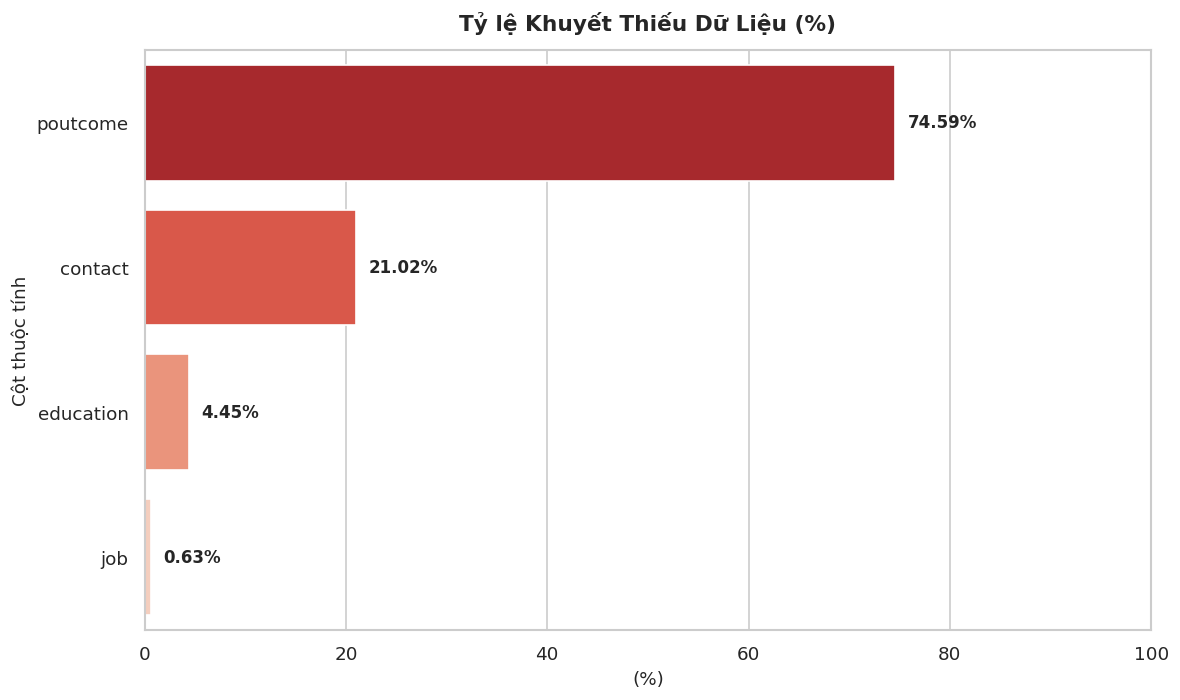

saved at E:\Downloads\BTL_ML_git\figures\01_missing_values.png


In [5]:
# Tạo bản sao thay thế 'unknown' thành np.nan để trực quan hóa khuyết thiếu
df_plot_missing = df.replace('unknown', np.nan)

fig, ax = plt.subplots(figsize=(10, 6))

# Tỷ lệ khuyết thiếu của các cột có giá trị thiếu
cols_with_missing = missing_df[missing_df['Tổng tỷ lệ thiếu (%)'] > 0]

sns.barplot(
    data=cols_with_missing,
    x='Tổng tỷ lệ thiếu (%)',
    y='Cột',
    hue='Cột',
    palette='Reds_r',
    legend=False,
    ax=ax
)
ax.set_title('Tỷ lệ Khuyết Thiếu Dữ Liệu (%)', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('(%)', fontsize=11)
ax.set_ylabel('Cột thuộc tính', fontsize=11)
ax.set_xlim(0, 100)

for p in ax.patches:
    width = p.get_width()
    ax.annotate(f"{width:.2f}%", 
                (width + 1.2, p.get_y() + p.get_height() / 2.),
                va='center', fontweight='bold', fontsize=10)

plt.tight_layout()

# Lưu hình ảnh vào thư mục figures
out_image_path = FIGURES_PATH / "01_missing_values.png"
plt.savefig(out_image_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"saved at {out_image_path}")

### 6. Kiểm tra Dữ liệu Trùng Lặp (Duplicated Rows)
Đếm và trích xuất các dòng bị trùng lặp hoàn toàn trên tất cả các thuộc tính.


In [6]:
# Đếm số dòng trùng lặp hoàn toàn
duplicate_count = df.duplicated().sum()
print("=== KIỂM TRA TRÙNG LẶP DỮ LIỆU ===")
print(f"- Số dòng bị trùng lặp hoàn toàn: {duplicate_count}")
print(f"- Tỷ lệ trùng lặp: {duplicate_count / len(df) * 100:.2f}%")

if duplicate_count > 0:
    print("\nDanh sách các dòng trùng lặp:")
    display(df[df.duplicated(keep=False)].sort_values(by=list(df.columns[:3])))
else:
    print("Tập dữ liệu sạch")


=== KIỂM TRA TRÙNG LẶP DỮ LIỆU ===
- Số dòng bị trùng lặp hoàn toàn: 0
- Tỷ lệ trùng lặp: 0.00%
Tập dữ liệu sạch


### 7. Phát hiện Các Giá trị Bất Thường (Anomalies & Inconsistencies)
Chúng ta tiến hành kiểm tra:
1. **Giá trị âm vô lý ở các cột số:** Các cột như `age` (tuổi), `duration` (thời lượng gọi), `campaign` (số lần gọi), `day` (ngày trong tháng) không thể nhận giá trị âm.
   - *Lưu ý nghiệp vụ:* 
     - Cột `balance` (số dư tài khoản): Giá trị âm biểu thị tình trạng thấu chi (overdraft) hoặc nợ tài khoản - điều này hoàn toàn hợp lệ trong thực tế ngân hàng.
     - Cột `pdays`: Giá trị `-1` là mã quy ước chuẩn của UCI Machine Learning biểu thị khách hàng chưa từng được liên hệ trong các chiến dịch trước đó.
2. **Giá trị chuỗi bất thường:** Kiểm tra khoảng trắng thừa (leading/trailing whitespace) hoặc các ký tự dị thường (ví dụ: `admin.` có dấu chấm ở cuối).


In [7]:
print("=== 1. KIỂM TRA GIÁ TRỊ ÂM Ở CÁC CỘT SỐ ===")
neg_summary = []
for col in num_cols:
    neg_mask = df[col] < 0
    neg_cnt = neg_mask.sum()
    min_val = df[col].min()
    neg_summary.append({
        'Tên cột': col,
        'Giá trị Min': min_val,
        'Số lượng âm': neg_cnt,
        'Tỷ lệ âm (%)': f"{neg_cnt / len(df) * 100:.2f}%",
        'Đánh giá': (
            'Hợp lệ (Thấu chi tài khoản)' if col == 'balance' and neg_cnt > 0 else
            'Quy ước chuẩn UCI (-1: chưa liên hệ)' if col == 'pdays' and neg_cnt > 0 else
            'Bất thường cần xử lý' if neg_cnt > 0 else 'Bình thường (Không có âm)'
        )
    })

neg_df = pd.DataFrame(neg_summary)
display(neg_df)

print()
print("=== 2. KIỂM TRA ĐỊNH DẠNG VÀ KHOẢNG TRẮNG Ở CỘT PHÂN LOẠI ===")
for col in cat_cols:
    unique_vals = df[col].unique().tolist()
    has_whitespace = any(isinstance(v, str) and (v != v.strip()) for v in unique_vals)
    print(f"Cột [{col}]: {len(unique_vals)} giá trị duy nhất")
    print(f"   - Mẫu giá trị: {unique_vals[:6]}")
    if has_whitespace:
        print(f"   [CẢNH BÁO] Cột {col} chứa khoảng trắng thừa ở đầu/cuối!")
    if col == 'job' and 'admin.' in unique_vals:
        print(f"   [GHI CHÚ] Cột 'job' có giá trị 'admin.' (kèm dấu chấm cuối chuỗi).")


=== 1. KIỂM TRA GIÁ TRỊ ÂM Ở CÁC CỘT SỐ ===


,Tên cột,Giá trị Min,Số lượng âm,Tỷ lệ âm (%),Đánh giá
0,age,18,0,0.00%,Bình thường (Không có âm)
1,balance,-6847,688,6.16%,Hợp lệ (Thấu chi tài khoản)
2,day,1,0,0.00%,Bình thường (Không có âm)
3,duration,2,0,0.00%,Bình thường (Không có âm)
4,campaign,1,0,0.00%,Bình thường (Không có âm)
5,pdays,-1,8324,74.57%,Quy ước chuẩn UCI (-1: chưa liên hệ)
6,previous,0,0,0.00%,Bình thường (Không có âm)



=== 2. KIỂM TRA ĐỊNH DẠNG VÀ KHOẢNG TRẮNG Ở CỘT PHÂN LOẠI ===
Cột [job]: 12 giá trị duy nhất
   - Mẫu giá trị: ['admin.', 'technician', 'services', 'management', 'retired', 'blue-collar']
   [GHI CHÚ] Cột 'job' có giá trị 'admin.' (kèm dấu chấm cuối chuỗi).
Cột [marital]: 3 giá trị duy nhất
   - Mẫu giá trị: ['married', 'single', 'divorced']
Cột [education]: 4 giá trị duy nhất
   - Mẫu giá trị: ['secondary', 'tertiary', 'primary', 'unknown']
Cột [default]: 2 giá trị duy nhất
   - Mẫu giá trị: ['no', 'yes']
Cột [housing]: 2 giá trị duy nhất
   - Mẫu giá trị: ['yes', 'no']
Cột [loan]: 2 giá trị duy nhất
   - Mẫu giá trị: ['no', 'yes']
Cột [contact]: 3 giá trị duy nhất
   - Mẫu giá trị: ['unknown', 'cellular', 'telephone']
Cột [month]: 12 giá trị duy nhất
   - Mẫu giá trị: ['may', 'jun', 'jul', 'aug', 'oct', 'nov']
Cột [poutcome]: 4 giá trị duy nhất
   - Mẫu giá trị: ['unknown', 'other', 'failure', 'success']
Cột [deposit]: 2 giá trị duy nhất
   - Mẫu giá trị: ['yes', 'no']


### 8. Định vị Điểm Dị Biệt (Outliers) bằng Biểu đồ Hộp (Boxplot)
Các cột dạng số có độ biến động lớn như `balance`, `duration`, `campaign`, `pdays`, `previous`, `age` sẽ được vẽ biểu đồ hộp (Boxplot) để định vị các điểm ngoại lai.
Đồng thời, áp dụng quy tắc **IQR (Interquartile Range)**:
- $IQR = Q_3 - Q_1$
- Ngưỡng dưới: $Lower = Q_1 - 1.5 	imes IQR$
- Ngưỡng trên: $Upper = Q_3 + 1.5 	imes IQR$

**Điều chỉnh kỹ thuật tối thiểu:** Với `pdays`, giá trị `-1` là mã sentinel “chưa từng liên hệ”, không phải số ngày. Vì vậy biểu đồ và IQR của riêng biến này chỉ dùng các bản ghi `pdays >= 0`; dữ liệu gốc không bị thay đổi.


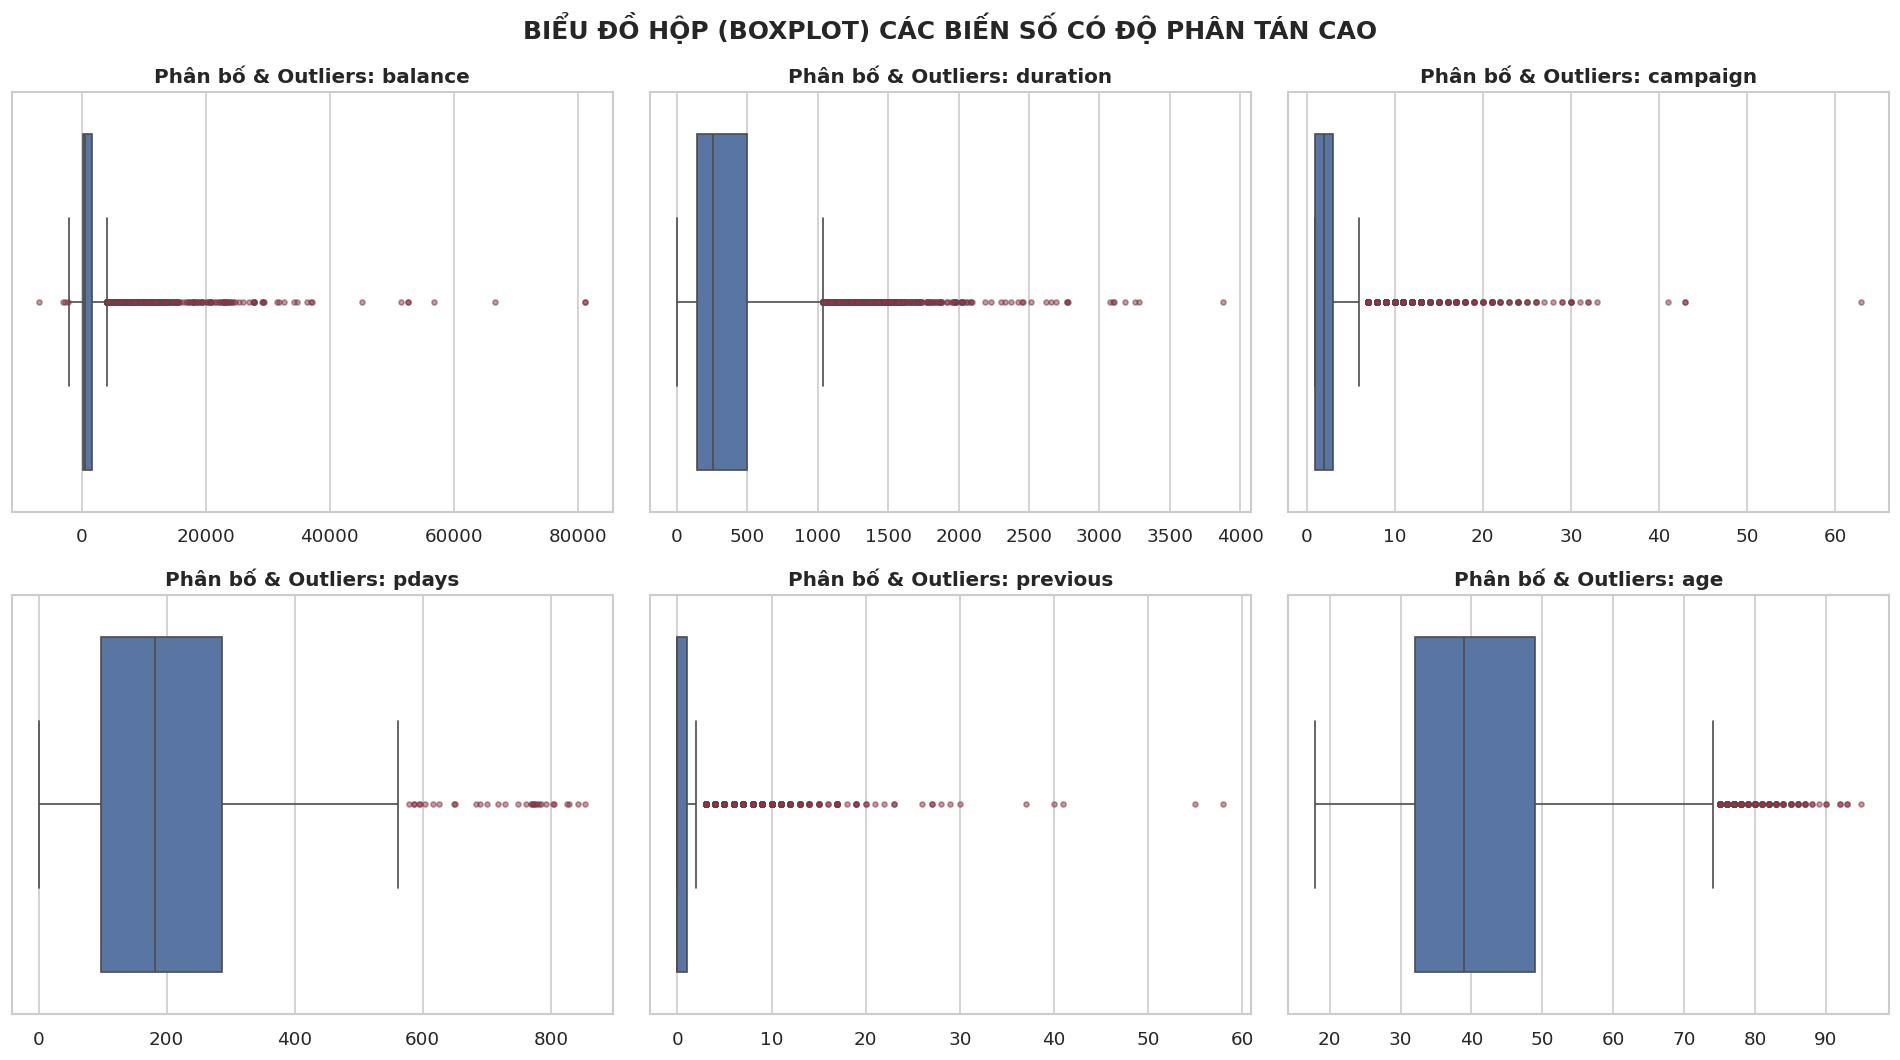

,Thuộc tính,Q1 (25%),Median (50%),Q3 (75%),IQR,Ngưỡng dưới,Ngưỡng trên,Số lượng Outlier,Tỷ lệ Outlier (%)
0,balance,122.0,550.0,1708.0,1586.0,-2257.0,4087.0,1055,9.45%
1,duration,138.0,255.0,496.0,358.0,-399.0,1033.0,636,5.70%
2,campaign,1.0,2.0,3.0,2.0,-2.0,6.0,601,5.38%
3,pdays,98.0,182.0,286.0,188.0,-184.0,568.0,32,1.13%
4,previous,0.0,0.0,1.0,1.0,-1.5,2.5,1258,11.27%
5,age,32.0,39.0,49.0,17.0,6.5,74.5,171,1.53%


In [8]:
# Chọn các cột số để vẽ Boxplot
plot_num_cols = ['balance', 'duration', 'campaign', 'pdays', 'previous', 'age']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(plot_num_cols):
    values = df.loc[df[col] >= 0, col] if col == 'pdays' else df[col]
    sns.boxplot(
        x=values,
        ax=axes[i],
        color='#4C72B0',
        flierprops={'marker': 'o', 'markersize': 3, 'markerfacecolor': 'crimson', 'alpha': 0.5}
    )
    axes[i].set_title(f"Phân bố & Outliers: {col}", fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')

plt.suptitle("BIỂU ĐỒ HỘP (BOXPLOT) CÁC BIẾN SỐ CÓ ĐỘ PHÂN TÁN CAO", fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()

# Lưu hình ảnh boxplot vào figures
boxplot_img_path = FIGURES_PATH / "01_outliers_boxplots.png"
plt.savefig(boxplot_img_path, dpi=300, bbox_inches='tight')
plt.show()

# Thống kê chi tiết số lượng Outliers theo phương pháp IQR
outlier_records = []
for col in plot_num_cols:
    values = df.loc[df[col] >= 0, col] if col == 'pdays' else df[col]
    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    outlier_count = ((values < lower_bound) | (values > upper_bound)).sum()
    
    outlier_records.append({
        'Thuộc tính': col,
        'Q1 (25%)': q1,
        'Median (50%)': values.median(),
        'Q3 (75%)': q3,
        'IQR': iqr,
        'Ngưỡng dưới': round(lower_bound, 2),
        'Ngưỡng trên': round(upper_bound, 2),
        'Số lượng Outlier': outlier_count,
        'Tỷ lệ Outlier (%)': f"{outlier_count / len(values) * 100:.2f}%"
    })

outlier_summary_df = pd.DataFrame(outlier_records)
outlier_summary_df


### 9. Bảng Tổng hợp Cấu trúc Dữ liệu phục vụ Báo cáo (Mục 2.1)
Bảng tổng hợp toàn bộ 17 thuộc tính với các thông số:
- **Tên biến**
- **Kiểu dữ liệu**
- **Tỷ lệ missing %** (bao gồm cả `NaN` và `unknown`)
- **Số lượng unique**
- **Diễn giải ý nghĩa nghiệp vụ**


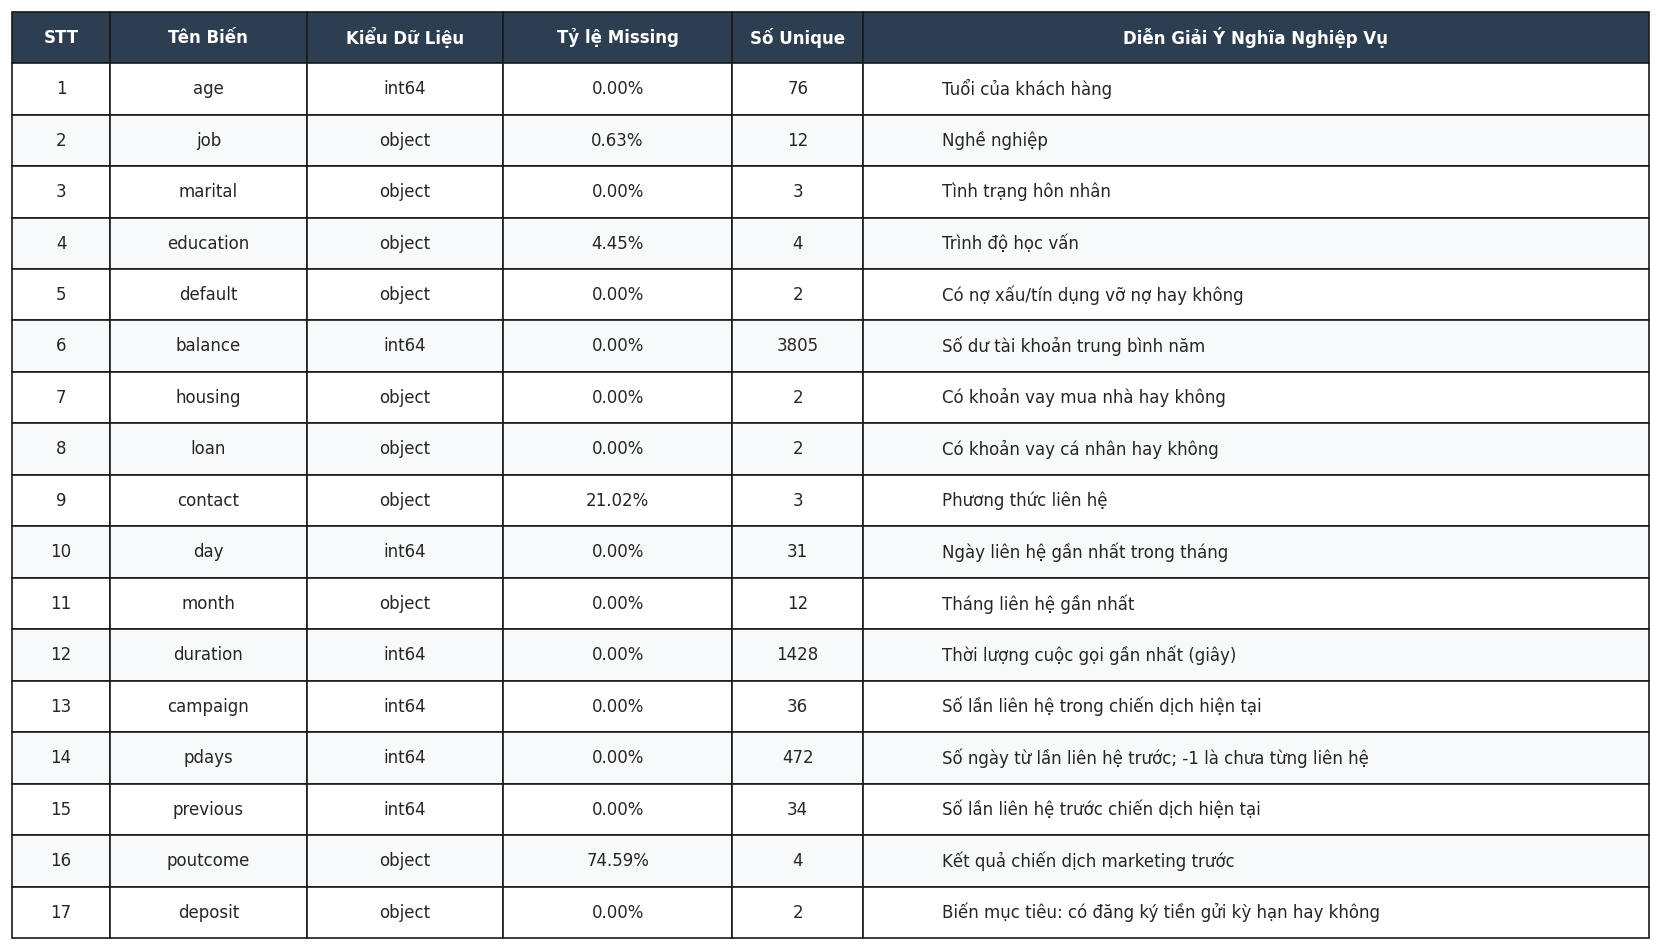

Đã xuất và lưu bảng báo cáo thành công tại: E:\Downloads\BTL_ML_git\figures\02_data_overview_report.png


In [9]:
# Khai báo bảng ngay trong notebook để loại bỏ phụ thuộc hidden state.
business_meanings = {
    'age': 'Tuổi của khách hàng',
    'job': 'Nghề nghiệp',
    'marital': 'Tình trạng hôn nhân',
    'education': 'Trình độ học vấn',
    'default': 'Có nợ xấu/tín dụng vỡ nợ hay không',
    'balance': 'Số dư tài khoản trung bình năm',
    'housing': 'Có khoản vay mua nhà hay không',
    'loan': 'Có khoản vay cá nhân hay không',
    'contact': 'Phương thức liên hệ',
    'day': 'Ngày liên hệ gần nhất trong tháng',
    'month': 'Tháng liên hệ gần nhất',
    'duration': 'Thời lượng cuộc gọi gần nhất (giây)',
    'campaign': 'Số lần liên hệ trong chiến dịch hiện tại',
    'pdays': 'Số ngày từ lần liên hệ trước; -1 là chưa từng liên hệ',
    'previous': 'Số lần liên hệ trước chiến dịch hiện tại',
    'poutcome': 'Kết quả chiến dịch marketing trước',
    'deposit': 'Biến mục tiêu: có đăng ký tiền gửi kỳ hạn hay không',
}
missing_lookup = missing_df.set_index('Cột')['Tổng tỷ lệ thiếu (%)']
report_2_1_df = pd.DataFrame({
    'STT': range(1, len(df.columns) + 1),
    'Tên Biến': df.columns,
    'Kiểu Dữ Liệu': [str(df[col].dtype) for col in df.columns],
    'Tỷ lệ Missing': [f"{missing_lookup[col]:.2f}%" for col in df.columns],
    'Số Unique': [df[col].nunique(dropna=False) for col in df.columns],
    'Diễn Giải Ý Nghĩa Nghiệp Vụ': [business_meanings[col] for col in df.columns],
})

import matplotlib.pyplot as plt

# 1. Cấu hình kích thước ảnh và tỷ lệ chiều rộng cho từng cột
# (Thứ tự tương ứng với các cột: STT, Tên Biến, Kiểu Dữ Liệu, Tỷ lệ Missing, Số Unique, Diễn Giải)
col_widths = [0.06, 0.12, 0.12, 0.14, 0.08, 0.48] 

fig_height = max(4, len(report_2_1_df) * 0.4 + 1.2)
fig, ax = plt.subplots(figsize=(14, fig_height))
ax.axis('off')
ax.axis('tight')

# 2. Đưa thêm tham số colWidths vào hàm table
table = ax.table(
    cellText=report_2_1_df.values,
    colLabels=report_2_1_df.columns,
    colWidths=col_widths,  # <-- Tự động phân chia chiều rộng cột tại đây
    cellLoc='center',
    loc='center'
)

# 3. Tinh chỉnh giao diện bảng
table.auto_set_font_size(False)
table.set_fontsize(10)

scale_factor_y = 1.5
for (row, col), cell in table.get_celld().items():
    cell.set_height(0.04 * scale_factor_y)
    
    # Căn lề trái riêng cho cột "Diễn Giải Ý Nghĩa Nghiệp Vụ" (cột cuối cùng) để dễ đọc
    if col == len(report_2_1_df.columns) - 1 and row > 0:
        cell.set_text_props(ha='left', va='center')
        # Thêm padding nhẹ bên trái cho đỡ sát mép khung
    
    if row == 0:
        cell.set_facecolor('#2c3e50')  # Màu nền tiêu đề (Xanh đậm)
        cell.set_text_props(weight='bold', color='white', ha='center')
    else:
        cell.set_facecolor('#f8f9fa' if row % 2 == 0 else '#ffffff')

plt.tight_layout()

# 4. Lưu hình ảnh vào thư mục figures
out_image_path = FIGURES_PATH / "02_data_overview_report.png"
plt.savefig(out_image_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Đã xuất và lưu bảng báo cáo thành công tại: {out_image_path}")